In [1]:
import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import numpy as np
import scipy
import torch

import conf
import apparaturs
import sim
import utils

In [2]:
torch.set_grad_enabled(False)
utils.overwrite_dnois_ray_march()

In [3]:
rcwa_t = scipy.io.loadmat('../data/RCWA/0620-reflective/t.mat')['results'][0]  #(12, 37, 13, 2, 2)
rcwa_k = scipy.io.loadmat('../data/RCWA/0620-reflective/k.mat')['k_results'][0]  #(12, 37, 13, 2, 3)

In [4]:
in_mode = 0  #0:TE,1:TM
out_mode = 0  #0:TE,1:TM

In [5]:
idx = list(range(rcwa_t.shape[2]))
# del idx[6]
print(
    np.allclose(rcwa_t[:, 0:9, idx, in_mode, out_mode], np.flip(rcwa_t, 2)[:, 18:9:-1, idx, in_mode, out_mode]),
    np.allclose(rcwa_t[:, 28:37, idx, in_mode, out_mode], np.flip(rcwa_t, 2)[:, 26:17:-1, idx, in_mode, out_mode])
)
# 数据是否关于y轴对称

False False


In [6]:
# rcwa_t[1, [0, 18], :, in_mode, out_mode]

In [7]:
# vis.vis_rcwa_t(rcwa_t[..., in_mode, out_mode][..., None])

In [8]:
complex_t = np.copy(rcwa_t[..., in_mode, out_mode])  #(12, 37, 13)
# np.allclose(complex_t[0,:,:6],-np.flip(complex_t[0,:,7:], 1))

idx = list(range(rcwa_t.shape[2]))
del idx[6]
np.allclose(complex_t[0, :18, idx], -complex_t[0, 18:36, idx])

True

In [9]:
complex_t = np.copy(rcwa_t[..., in_mode, out_mode])  #(12, 37, 13)
# complex_t[0, :, (complex_t.shape[-1] + 1) // 2:] = -complex_t[0, :, (complex_t.shape[-1] + 1) // 2:]
# complex_t[0, 9:27] = -complex_t[0, 9:27]
# complex_t[0, 9:27, 6] = -complex_t[0, 9:27, 6]
transmittance = np.abs(complex_t)
phase_shift = np.angle(complex_t)

out_d = np.copy(rcwa_k[..., in_mode, :])  #(12, 37, 13, 3)
# RCWA中坐标系的XZ轴恰与DNOIS中的相反
out_d[..., [0, 2]] = -out_d[..., [0, 2]]
# out_d[..., 0] = -out_d[..., 0]
# out_d[..., :2] = np.flip(out_d[..., :2], (-1,))

In [10]:
sq = apparaturs.layout_reflective(transmittance, phase_shift, out_d)
print(sq)

CoaxialSurfaceSequence(
  (0): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.00625m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.012906m)
    (context): CoaxialContext(distance=0.00625m)
  )
  (1): CustomizedGrating(
    material=vacuum, reflective=True
    (aperture): CircularAperture(radius=0.008m)
    (context): CoaxialContext(distance=-0.00625m)
  )
  (2): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.00625m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.012906m)
    (context): CoaxialContext(distance=-0.00625m)
  )
  (3): CircularStop(
    material=vacuum, reflective=False
    (aperture): CircularAperture(radius=0.012906m)
    (context): CoaxialContext(distance=-0.0625m)
  )
  (4): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.0625m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.12906m)
    (context): CoaxialContext(distance=-0.0625m)
  )
)


In [11]:
resolution = 256
image_width = 0.1e-3
sensor = dnois.sensor.Sensor(resolution, image_width / resolution)
optics = rt.CoaxialRayTracing(sq, sensor, wl=conf.wl, depth=sq.first.fl1).double()

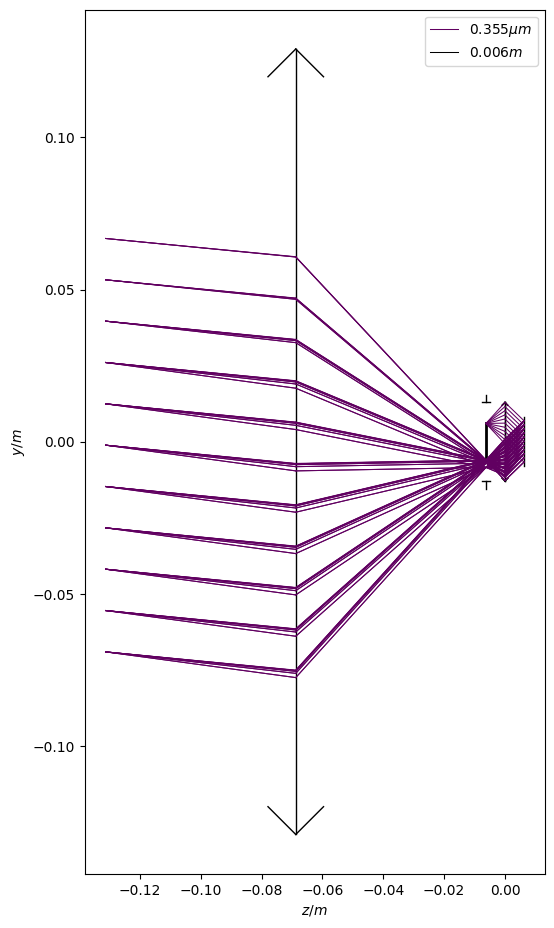

In [13]:
_ = optics.plot_cross_section(height=0e-3, init_rays=20)

# 成像模拟
## 单点

In [ ]:
sampling_size = 128
point = optics.new_tensor([0, 0, -optics.depth.squeeze().item()]).unsqueeze(0)
ray_in, ray_out = sim.trace(optics, sampling_size, point)

In [ ]:
grating = sq[1]
interpolators = sim.make_interpolators(ray_out, 1, grating.n_order)

In [ ]:
y, x = dnois.utils.grid(sensor.resolution, sensor.pixel_size, symmetric=True, device='cpu')
y = -y
# x=x.contiguous()-5e-3
interpolated_field = sim.interpolate(interpolators, x, y)

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(interpolated_field.cpu().numpy())
# ax.set(xticks=[], yticks=[])
fig.colorbar(im, ax=ax)

In [ ]:
fig, ax = plt.subplots(figsize=(20, 4))
x = np.linspace(-sensor.w / 2, sensor.w / 2, sensor.res_w) * 1e6
ax.plot(x, (interpolated_field[sensor.res_h // 2].abs().square().cpu().numpy()))
# ax.plot(x, (interpolated_field.angle()[sensor.res_h//2].cpu().numpy()))
ax.set(xlabel='x/um')

In [ ]:
# plt.imsave('interpolated.png', interpolated_field.abs().square().cpu().numpy(), cmap='viridis')

## 面光源

In [ ]:
radius = 12.906e-3 / 2
depth = optics.depth.squeeze().item()

In [ ]:
# points = sim.make_points(-depth, radius).unsqueeze(1)  #(N_s,1,3)
# points = sim.make_more_points(-depth, radius).unsqueeze(1)  #(N_s,1,3)
points = sim.make_17_points(-depth, radius).unsqueeze(1)  #(N_s,1,3)
points = points.to(device=optics.device, dtype=optics.dtype)
n_s = points.size(0)

In [ ]:
points.shape

In [ ]:
ray_in, ray_out = sim.trace(optics, sampling_size, points, conf.wl)
n_spp = ray_in.shape[-1]

In [ ]:
grating = sq[1]
interpolators = sim.make_interpolators(ray_out, n_s, grating.n_order)

In [ ]:
y, x = dnois.utils.grid(sensor.resolution, sensor.pixel_size, symmetric=True, device='cpu')

In [ ]:
interpolated_field = sim.interpolate(interpolators, x, y)

In [ ]:
fig, ax = plt.subplots()
ax.imshow(dnois.torch.abs2(interpolated_field).cpu().numpy())
# ax.set(xticks=[], yticks=[])
# plt.colorbar()

In [ ]:
fig, ax = plt.subplots(figsize=(20, 4))
x = np.linspace(-sensor.w / 2, sensor.w / 2, sensor.res_w) * 1e6
ax.plot(x, (interpolated_field[sensor.res_h // 2].abs().square().cpu().numpy()))
# ax.plot(x, (interpolated_field.angle()[sensor.res_h//2].cpu().numpy()))
ax.set(xlabel='x/um')